In [4]:
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import Delaunay, cKDTree
import os
import spatialdata as sd
import heapq
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from napari_spatialdata import Interactive 
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns


In [2]:
dirs = os.listdir("C://Users//laure//Desktop//github//sys_gen//zarr")

In [3]:
dirs

['human_bone_marrow_acute_lymphoid_leukemia',
 'human_brain_preview',
 'human_non_diseased_lung',
 'mouse_bone_formic_acid_decalcification',
 'mouse_brain_replicate_1',
 'mouse_colon']

In [5]:
sdata = sd.read_zarr("C://Users//laure//Desktop//github//sys_gen//zarr//" + dirs[4])
adata = sdata.tables["table"]

In [9]:
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=1)

In [10]:
adata

AnnData object with n_obs × n_vars = 162033 × 248
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'dist_neighbors', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'dist_connectivities', 'dist_distances', 'spatial_connectivities', 'spatial_distances'

C:\Users\laure\AppData\Local\Temp\ipykernel_14412\4136113822.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


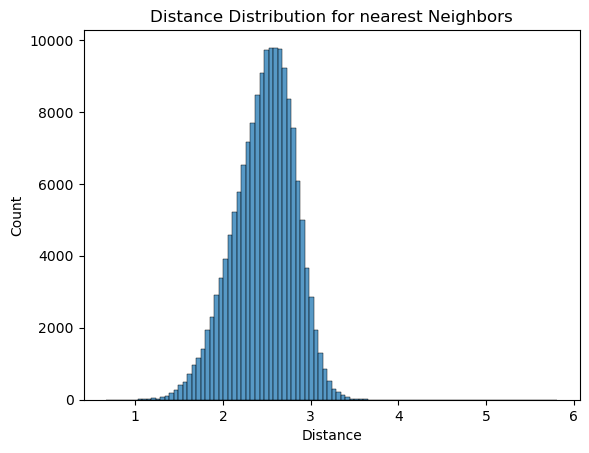

In [12]:
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=1)
histogram = sns.histplot(np.log(adata.obsp["spatial_distances"].data), bins=100)
histogram.set_title(f"Distance Distribution for nearest Neighbors")
histogram.set_xlabel("Distance")
fig = histogram.get_figure()
        
fig.show()

In [14]:
np.log(adata.obsp["spatial_distances"].data)


array([2.48913704, 2.53073148, 2.48228857, ..., 2.27315998, 2.48026231,
       2.42068401], shape=(162033,))

In [15]:
adata

AnnData object with n_obs × n_vars = 162033 × 248
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'dist_neighbors', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'dist_connectivities', 'dist_distances', 'spatial_connectivities', 'spatial_distances'

In [5]:
coords = sdata.tables["table"].obsm["spatial"]

In [6]:
def _get_distances(adata, k):
    coords = adata.obsm["spatial"]
    k_density = 1

    tree = cKDTree(coords)
    dists, _ = tree.query(coords, k=k_density + 1)
    h = np.log(dists[:, k_density])  # scalar field
    n = len(h)
    return h,n,tree

def _get_neighbors(coords, tree, type):

    if type == "delaunay":
        tri = Delaunay(coords)

        neighbors = {i: set() for i in range(n)}
        for simplex in tri.simplices:
            for i in range(3):
                for j in range(i + 1, 3):
                    a, b = simplex[i], simplex[j]
                    neighbors[a].add(b)
                    neighbors[b].add(a)
    else:
        k_adj = 100  # typical planar degree

        _, idx = tree.query(coords, k=k_adj + 1)

        neighbors = {i: set() for i in range(n)}
        for i in range(n):
            for j in idx[i, 1:]:
                neighbors[i].add(j)
                neighbors[j].add(i)
    return neighbors

def _set_seeds(h, neighbors, n):
    labels = np.zeros(n, dtype=int)
    current_label = 1

    for i in range(n):
        if all(h[i] <= h[j] for j in neighbors[i]):
            labels[i] = current_label
            current_label += 1
    return labels

def _watershed(h, neighbors, labels, n):

    # Priority queue ordered by scalar value
    pq = []

    for i in range(n):
        if labels[i] > 0:
            heapq.heappush(pq, (h[i], i))

    visited = labels > 0

    while pq:
        _, i = heapq.heappop(pq)

        for j in neighbors[i]:
            if not visited[j]:
                labels[j] = labels[i]
                visited[j] = True
                heapq.heappush(pq, (h[j], j))
    return labels

In [7]:
sdata.tables["table"].obs["distances"] ,_ ,_= _get_distances(sdata.tables["table"], k=5)

In [8]:
# distances: 1D array of nth-nearest-neighbor distances
distances = np.asarray(sdata.tables["table"].obs["distances"].values)

gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=0
)

labels = gmm.fit_predict(distances.reshape(-1, 1))

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\subprocess.py", line 1601, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte
c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible a

In [9]:
sdata.tables["table"].obs["gmm"] = labels

In [10]:
adata_0 = sdata.tables["table"][sdata.tables["table"].obs["gmm"] == 0] 
adata_1 = sdata.tables["table"][sdata.tables["table"].obs["gmm"] == 1]
adata_2 = sdata.tables["table"][sdata.tables["table"].obs["gmm"] == 2]
adata_3 = sdata.tables["table"][sdata.tables["table"].obs["gmm"] == 3]
adata_4 = sdata.tables["table"][sdata.tables["table"].obs["gmm"] == 4]

coords_0 = adata_0.obsm["spatial"]
coords_1 = adata_1.obsm["spatial"]
coords_2 = adata_2.obsm["spatial"]
coords_3 = adata_3.obsm["spatial"]
coords_4 = adata_4.obsm["spatial"]

In [11]:
dist, n, tree = _get_distances(adata_0, 5)
neighs = _get_neighbors(coords_0, tree, "knn")
labels = _set_seeds(dist, neighs, n)
niches_0 = _watershed(dist, neighs, labels, n)

dist, n, tree = _get_distances(adata_1, 5)
neighs = _get_neighbors(coords_1, tree, "knn")
labels = _set_seeds(dist, neighs, n)
niches_1 = _watershed(dist, neighs, labels, n)

dist, n, tree = _get_distances(adata_2, 5)
neighs = _get_neighbors(coords_2, tree, "knn")
labels = _set_seeds(dist, neighs, n)
niches_2 = _watershed(dist, neighs, labels, n)

dist, n, tree = _get_distances(adata_3, 5)
neighs = _get_neighbors(coords_3, tree, "knn")
labels = _set_seeds(dist, neighs, n)
niches_3 = _watershed(dist, neighs, labels, n)

dist, n, tree = _get_distances(adata_4, 5)
neighs = _get_neighbors(coords_4, tree, "knn")
labels = _set_seeds(dist, neighs, n)
niches_4 = _watershed(dist, neighs, labels, n)

In [12]:
adata_0.obs["niches"] = niches_0
adata_1.obs["niches"] = niches_1
adata_2.obs["niches"] = niches_2
adata_3.obs["niches"] = niches_3
adata_4.obs["niches"] = niches_4

C:\Users\laure\AppData\Local\Temp\ipykernel_15264\2748634459.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_0.obs["niches"] = niches_0
C:\Users\laure\AppData\Local\Temp\ipykernel_15264\2748634459.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_1.obs["niches"] = niches_1
C:\Users\laure\AppData\Local\Temp\ipykernel_15264\2748634459.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_2.obs["niches"] = niches_2
C:\Users\laure\AppData\Local\Temp\ipykernel_15264\2748634459.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_3.obs["niches"] = niches_3
C:\Users\laure\AppData\Local\Temp\ipykernel_15264\2748634459.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_4.obs["niche

In [13]:
adata_merged = adata_0.concatenate(adata_1, adata_2, adata_3, adata_4)

C:\Users\laure\AppData\Local\Temp\ipykernel_15264\3296680462.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = adata_0.concatenate(adata_1, adata_2, adata_3, adata_4)


In [14]:
sdata.tables["table"].obs = sdata.tables["table"].obs.merge(
    adata_merged.obs[["cell_id", "niches"]],
    on="cell_id",
    how="left"
)


c:\Users\laure\anaconda3\envs\new_spatial\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [15]:
#sdata.tables["table"].obs["niches"] = segmentation
sdata.tables["table"].obs["niches"] = sdata.tables["table"].obs["niches"].astype("category")

In [16]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def assign_randomized_colors(n, cmap_name="hsv", seed=42):
    rng = np.random.default_rng(seed)
    indices = np.linspace(0, 1, n, endpoint=False)
    rng.shuffle(indices)

    cmap = cm.get_cmap(cmap_name)
    return [mcolors.to_hex(cmap(i)) for i in indices]


sdata.tables["table"].uns["niches_colors"] = assign_randomized_colors(sdata.tables["table"].obs["niches"].nunique())


C:\Users\laure\AppData\Local\Temp\ipykernel_15264\268180999.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


In [ ]:
Interactive(sdata)

2026-01-20 23:32:40.412 | WARNING  | napari_spatialdata._viewer:__init__:57 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


2026-01-20 23:32:45.279 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-01-20 23:32:45.447 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
c:\Users\laure\anaconda3\envs\new_spatial\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\laure\anaconda3\envs\new_spatial\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\laure\anaconda3\envs\new_spatial\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\laure\anaconda3\envs\new_spatial\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\laure\anaconda3\envs\new_spatial\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index

In [18]:
sdata.tables["table"].obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,region,distances,gmm,niches
0,1,327,0,0,327,240.953750,63.038125,cell_circles,2.489137,3,725
1,2,354,0,0,354,211.692500,65.476562,cell_circles,2.530731,3,725
2,3,422,0,0,422,186.946875,69.540625,cell_circles,2.482289,3,725
3,4,250,0,0,250,239.237813,61.728594,cell_circles,2.558219,1,839
4,5,550,1,0,552,438.692969,92.209063,cell_circles,2.387596,3,725
...,...,...,...,...,...,...,...,...,...,...,...
162028,162029,555,0,0,557,515.955312,76.991406,cell_circles,2.840351,1,912
162029,162030,266,0,0,266,268.002344,13.637188,cell_circles,2.636120,1,912
162030,162031,488,0,1,489,346.483906,77.036563,cell_circles,2.273160,4,179
162031,162032,176,0,0,176,169.922969,9.889219,cell_circles,2.480262,3,231


In [24]:
# example column names
cat_col = "niches"
num_col = "distances"

# compute mean per category
means = (
    sdata.tables["table"].obs.groupby(cat_col)[num_col]
      .mean()
      .sort_values(ascending=True)
)

# plot
plt.figure()
means.plot()
plt.xticks([])                 # removes tick labels
plt.ylabel(f"Mean {num_col}")
plt.tight_layout()
plt.savefig("mean_dist_by_niche.png", dpi=300)
plt.close()

C:\Users\laure\AppData\Local\Temp\ipykernel_15264\390897443.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables["table"].obs.groupby(cat_col)[num_col]


In [25]:
# example column names
cat_col = "niches"
num_col = "cell_area"

# compute mean per category
means = (
    sdata.tables["table"].obs.groupby(cat_col)[num_col]
      .mean()
      .sort_values(ascending=True)
)

# plot
plt.figure()
means.plot()
plt.xticks([])                 # removes tick labels
plt.ylabel(f"Mean {num_col}")
plt.tight_layout()
plt.savefig("mean_cell_area_by_niche.png", dpi=300)
plt.close()

C:\Users\laure\AppData\Local\Temp\ipykernel_15264\464034044.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables["table"].obs.groupby(cat_col)[num_col]
